In [ ]:
import sys
sys.path.append("/home/cyf/wbi/Virginia/code")
from CoarseFlow.datasets.synthetic_dataset import (
    build_sameShape_loader,
    summarize_manifest,
)
import json
import baseline as bl

MANIFEST_SUMMARY_PATH = "/home/cyf/wbi/Virginia/code/CoarseFlow/cached_datasets/coarseflow_v6/manifest_summary.json"

with open(MANIFEST_SUMMARY_PATH, "r") as f:
    manifest_summary = json.load(f)

val_loader_stage3, _, _ = build_sameShape_loader(
    manifest_summary["stage2_val"],
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
)

# === Baseline 1: ZNCC + argmax + radius=(2,1,1) ===
df_zncc = bl.evaluate_ncc_baseline_on_loader(
    loader=val_loader_stage3,
    dataset_name="stage3.1_val",
    max_batches=5,
    device="cuda",
    radius=(4, 3, 3),
    patch_size=8,
    control_stride=16,
    xy_step=8,
    z_step=1,
    temperature=0.05,
    topk=(1, 3, 5),
    match_mode="argmax",
    similarity="zncc",
)

# === Baseline 2: SSD + argmax + radius=(2,1,1) ===
df_ssd = bl.evaluate_ncc_baseline_on_loader(
    loader=val_loader_stage3,
    dataset_name="stage3.1_val",
    max_batches=5,
    device="cuda",
    radius=(4, 3, 3),
    patch_size=8,
    control_stride=16,
    xy_step=8,
    z_step=1,
    temperature=0.05,
    topk=(1, 3, 5),
    match_mode="argmax",
    similarity="ssd",
)


[SameShapeBatchSampler] groups:
  key=(K,D,H,W)=(3, 20, 256, 256), n=51
  key=(K,D,H,W)=(3, 30, 256, 256), n=21
  key=(K,D,H,W)=(5, 20, 256, 256), n=60
  key=(K,D,H,W)=(5, 30, 256, 256), n=12
  key=(K,D,H,W)=(7, 20, 256, 256), n=62
  key=(K,D,H,W)=(7, 30, 256, 256), n=10
[stage3.1_val] batch=0 | CE=6.2448 | top1=0.1628 | top5=0.3330
[stage3.1_val] batch=0 | CE=5.5528 | top1=0.1634 | top5=0.3636


In [2]:
# ZNCC baseline
df_zncc


,sample,ce_loss,inside_valid,target_dist_min_mean,target_dist_min_p95,gt_inside_threshold,top1,top3,top5,dataset,batch_idx
0,0,3.598874,1.0,1.115288,1.730765,1.0,0.319010,0.479167,0.540365,stage3.1_val,0
1,1,5.149421,1.0,1.290210,2.015461,1.0,0.184896,0.329427,0.398438,stage3.1_val,0
2,2,8.341444,1.0,2.284230,3.674184,1.0,0.091146,0.173177,0.221354,stage3.1_val,0
3,3,7.889572,1.0,3.135666,4.526270,1.0,0.055990,0.102865,0.171875,stage3.1_val,0
4,0,6.036417,1.0,1.835395,3.981596,1.0,0.265625,0.368490,0.414062,stage3.1_val,1
5,1,8.289810,1.0,2.220927,3.913335,1.0,0.128906,0.204427,0.236979,stage3.1_val,1
6,2,6.743957,1.0,1.968329,3.469184,1.0,0.174479,0.251302,0.282552,stage3.1_val,1
7,3,8.941441,1.0,2.072435,3.472048,1.0,0.066406,0.128906,0.180990,stage3.1_val,1
8,0,9.420386,1.0,2.478098,3.899703,1.0,0.044271,0.097656,0.139323,stage3.1_val,2
9,1,11.127376,1.0,3.350208,4.145090,1.0,0.020833,0.049479,0.067708,stage3.1_val,2


In [3]:
# SSD baseline
df_ssd


,sample,ce_loss,inside_valid,target_dist_min_mean,target_dist_min_p95,gt_inside_threshold,top1,top3,top5,dataset,batch_idx
0,0,5.659408,1.0,1.115288,1.730765,1.0,0.209635,0.377604,0.453125,stage3.1_val,0
1,1,5.497198,1.0,1.290210,2.015461,1.0,0.199219,0.322917,0.360677,stage3.1_val,0
2,2,5.779316,1.0,2.284230,3.674184,1.0,0.157552,0.278646,0.339844,stage3.1_val,0
3,3,5.275309,1.0,3.135666,4.526270,1.0,0.087240,0.220052,0.300781,stage3.1_val,0
4,0,5.518039,1.0,1.835395,3.981596,1.0,0.259115,0.393229,0.455729,stage3.1_val,1
5,1,5.572142,1.0,2.220927,3.913335,1.0,0.165365,0.260417,0.311198,stage3.1_val,1
6,2,5.477201,1.0,1.968329,3.469184,1.0,0.222656,0.347656,0.415365,stage3.1_val,1
7,3,5.726687,1.0,2.072435,3.472048,1.0,0.041667,0.095052,0.126302,stage3.1_val,1
8,0,5.701519,1.0,2.478098,3.899703,1.0,0.078125,0.170573,0.239583,stage3.1_val,2
9,1,5.514175,1.0,3.350208,4.145090,1.0,0.050781,0.085938,0.118490,stage3.1_val,2


In [4]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from CoarseFlow.training.inference import CoarseFlowInferenceConfig, CoarseFlowPredictor

def load_coarseflow_predictor_from_pth(pth_path,
        model_module="CoarseFlow.models.SparseGMFlow3D_v2",
        model_class="CoarseMatchingNetV6", device="cuda:0",
        use_amp=False, strict_load=True):
    cfg = CoarseFlowInferenceConfig(
        pth_path=pth_path, model_config=None,
        model_module=model_module, model_class=model_class,
        device=device, strict_load=strict_load, use_amp=use_amp,
    )
    predictor = CoarseFlowPredictor(cfg)
    predictor.model.eval()
    print("Loaded:", pth_path)
    print("load_msg:", predictor.load_msg)
    print("model_config:", predictor.model_config)
    return predictor


In [5]:
@torch.no_grad()
def compute_model_match_metrics(outputs, gt_coords_raw, valid_mask=None, topk=(1,3,5)):
    """Compute CE/top-k for a SINGLE sample (B=1)."""
    scores = outputs["scores"]              # (1, N, M)
    cand_feat = outputs["candidate_coords_feat"]
    cand_valid = outputs["candidate_valid_mask"].bool()
    coord_scale = outputs["coord_scale"]
    device = scores.device
    gt_coords_raw = gt_coords_raw.to(device=device, dtype=torch.float32)  # (1, K, Hc, Wc, 3)

    B, N, M = scores.shape
    K, Hc, Wc = gt_coords_raw.shape[1:4]
    assert N == K * Hc * Wc

    cand_raw = cand_feat * coord_scale.view(1, 1, 1, 3)
    gt_flat = gt_coords_raw.reshape(B, N, 3)
    if valid_mask is not None:
        valid_flat = valid_mask.to(device).bool().reshape(B, N)
    else:
        valid_flat = torch.ones((B, N), dtype=torch.bool, device=device)

    logits = scores.masked_fill(~cand_valid, -1e4)
    dist = torch.linalg.norm(cand_raw - gt_flat[:, :, None, :], dim=-1)
    dist = dist.masked_fill(~cand_valid, float("inf"))
    target_idx = torch.argmin(dist, dim=-1)

    has_valid = torch.isfinite(dist.gather(dim=-1, index=target_idx[..., None]).squeeze(-1))
    query_valid = valid_flat & has_valid

    if query_valid.sum() == 0:
        out = {"ce_loss": np.nan}
        for kk in topk: out[f"top{kk}"] = np.nan
        return out

    logits_f = logits.reshape(B * N, M)
    target_f = target_idx.reshape(B * N)
    valid_f = query_valid.reshape(B * N)
    ce = F.cross_entropy(logits_f[valid_f], target_f[valid_f], reduction="none")
    rank = torch.argsort(logits_f, dim=-1, descending=True)

    out = {"ce_loss": float(ce.mean().detach().cpu())}
    for kk in topk:
        hit = (rank[:, :kk] == target_f[:, None]).any(dim=1)
        out[f"top{kk}"] = float(hit[valid_f].float().mean().detach().cpu())
    return out


@torch.no_grad()
def evaluate_model_on_batch(predictor, batch, device="cuda:0", topk=(1,3,5)):
    """Returns one row per SAMPLE (like NCC baseline)."""
    model = predictor.model
    model.eval()
    mov = batch["mov"].to(device)   # (B,1,K,H,W)
    ref = batch["ref"].to(device)   # (B,1,D,H,W)

    # z_init
    if "z_init" in batch:
        z_init = batch["z_init"].to(device)
    elif "sparse_z_idx" in batch:
        z_init = batch["sparse_z_idx"].to(device)
    else:
        raise KeyError("batch must contain z_init or sparse_z_idx")

    # spacing
    if "spacing" in batch:
        spacing = batch["spacing"].to(device)
    else:
        B = mov.shape[0]
        spacing = torch.tensor([1.0]*6, dtype=torch.float32, device=device)[None].expand(B, -1)
    if spacing.shape[-1] == 3:
        spacing = torch.cat([spacing, spacing], dim=-1)

    # gt_coords
    if "gt_coords" in batch:
        gt_coords = batch["gt_coords"].to(device)
    elif "gt_coords_ctrl" in batch:
        gt_coords = batch["gt_coords_ctrl"].to(device)
    else:
        raise KeyError("batch must contain gt_coords or gt_coords_ctrl")

    # valid_mask
    if "valid_mask" in batch:
        valid_mask = batch["valid_mask"].to(device)
    elif "valid" in batch:
        valid_mask = batch["valid"].to(device)
    else:
        valid_mask = None

    # Run full-batch forward once
    outputs = model(mov=mov, ref=ref, z_init=z_init, spacing=spacing, return_match_aux=True)

    # Split by sample and compute per-sample metrics
    # (coord_scale is global (3,), shared across batch — keep as-is)
    B = mov.shape[0]
    rows = []
    GLOBAL_KEYS = {'coord_scale'}
    for b in range(B):
        out_b = {k: (v if k in GLOBAL_KEYS else v[b:b+1])
                 for k, v in outputs.items() if torch.is_tensor(v)}
        gt_b = gt_coords[b:b+1]
        valid_b = valid_mask[b:b+1] if valid_mask is not None else None
        metrics = compute_model_match_metrics(out_b, gt_b, valid_b, topk)
        row = {"sample": b}
        row.update(metrics)
        rows.append(row)

    return rows


def evaluate_model_on_loader(predictor, loader, dataset_name="val",
                              max_batches=None, device="cuda:0", topk=(1,3,5)):
    rows = []
    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        batch_rows = evaluate_model_on_batch(predictor, batch, device, topk)
        for r in batch_rows:
            r["dataset"] = dataset_name
            r["batch_idx"] = batch_idx
            rows.append(r)
        if batch_idx % 5 == 0:
            tmp = pd.DataFrame(rows)
            ce = tmp['ce_loss'].mean()
            t1 = tmp['top1'].mean()
            t5 = tmp['top5'].mean()
            print(f'[Model {dataset_name}] batch={batch_idx} | CE={ce:.4f} | top1={t1:.4f} | top5={t5:.4f}')
    return pd.DataFrame(rows)


In [6]:
pth_path = "/home/cyf/wbi/Virginia/code/CoarseFlow/scripys/checkpoints/coarse_matching_v0527/best.pth"

predictor = load_coarseflow_predictor_from_pth(
    pth_path=pth_path,
    model_module="CoarseFlow.models.SparseGMFlow3D_v2",
    model_class="CoarseMatchingNetV6",
    device="cuda:0",
)

df_model = evaluate_model_on_loader(
    predictor=predictor,
    loader=val_loader_stage3,
    dataset_name="stage2_val",
    max_batches=5,
    device="cuda:0",
    topk=(1, 3, 5),
)

df_model


Loaded: /home/cyf/wbi/Virginia/code/CoarseFlow/scripys/checkpoints/coarse_matching_v0527/best.pth
load_msg: <All keys matched successfully>
model_config: {'dim': 96, 'radius': (4, 3, 3), 'temperature': 0.05, 'use_learned_matching': True, 'matcher_mode': 'hybrid', 'control_stride': 16, 'num_refine_iters': 1, 'encoder_stride': 8, 'query_chunk_size': 256, 'moving_base_channels': (24, 48, 96), 'moving_num_blocks': (2, 4, 4), 'moving_mlp_ratio': 2.0, 'moving_window_attn_layers': 6, 'moving_window_size': 8, 'moving_attn_num_heads': 4, 'moving_slice_fusion_blocks': 1, 'ref_base_channels': (24, 48, 96), 'ref_num_blocks': (2, 4, 4), 'ref_refine_blocks': 1, 'ref_mlp_ratio': 2.0, 'ref_attn_layers': 6, 'ref_attn_num_heads': 4, 'ref_attn_window_size': (4, 8, 8), 'ref_attn_mlp_ratio': 2.0, 'use_coord_embed': True, 'use_spacing_embed': True, 'use_offset_encoding': True, 'use_offset_bias': True, 'use_local_cross_attn': True, 'local_attn_temperature': 0.2, 'matcher_cross_attn_layers': 3, 'matcher_cross

,sample,ce_loss,top1,top3,top5,dataset,batch_idx
0,0,1.061344,0.667969,0.963542,0.993490,stage2_val,0
1,1,1.071907,0.729167,0.971354,0.989583,stage2_val,0
2,2,1.313805,0.700521,0.916667,0.966146,stage2_val,0
3,3,1.507385,0.683594,0.880208,0.972656,stage2_val,0
4,0,1.248111,0.660156,0.925781,0.979167,stage2_val,1
5,1,1.420373,0.661458,0.908854,0.964844,stage2_val,1
6,2,1.299358,0.643229,0.901042,0.970052,stage2_val,1
7,3,0.939243,0.839844,0.972656,0.993490,stage2_val,1
8,0,1.381811,0.645833,0.911458,0.970052,stage2_val,2
9,1,1.337132,0.705729,0.917969,0.970052,stage2_val,2


In [51]:
# CoarseFlow Model
df_model


,sample,ce_loss,top1,top3,top5,dataset,batch_idx
0,0,1.061344,0.667969,0.963542,0.993490,stage2_val,0
1,1,1.071907,0.729167,0.971354,0.989583,stage2_val,0
2,2,1.313805,0.700521,0.916667,0.966146,stage2_val,0
3,3,1.507385,0.683594,0.880208,0.972656,stage2_val,0
4,0,1.248111,0.660156,0.925781,0.979167,stage2_val,1
5,1,1.420373,0.661458,0.908854,0.964844,stage2_val,1
6,2,1.299358,0.643229,0.901042,0.970052,stage2_val,1
7,3,0.939243,0.839844,0.972656,0.993490,stage2_val,1
8,0,1.381811,0.645833,0.911458,0.970052,stage2_val,2
9,1,1.337132,0.705729,0.917969,0.970052,stage2_val,2


Saved fig_baseline_bar.pdf / .png
Saved fig_legend.pdf / .png


/tmp/ipykernel_929815/1458540012.py:107: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig_leg.tight_layout()


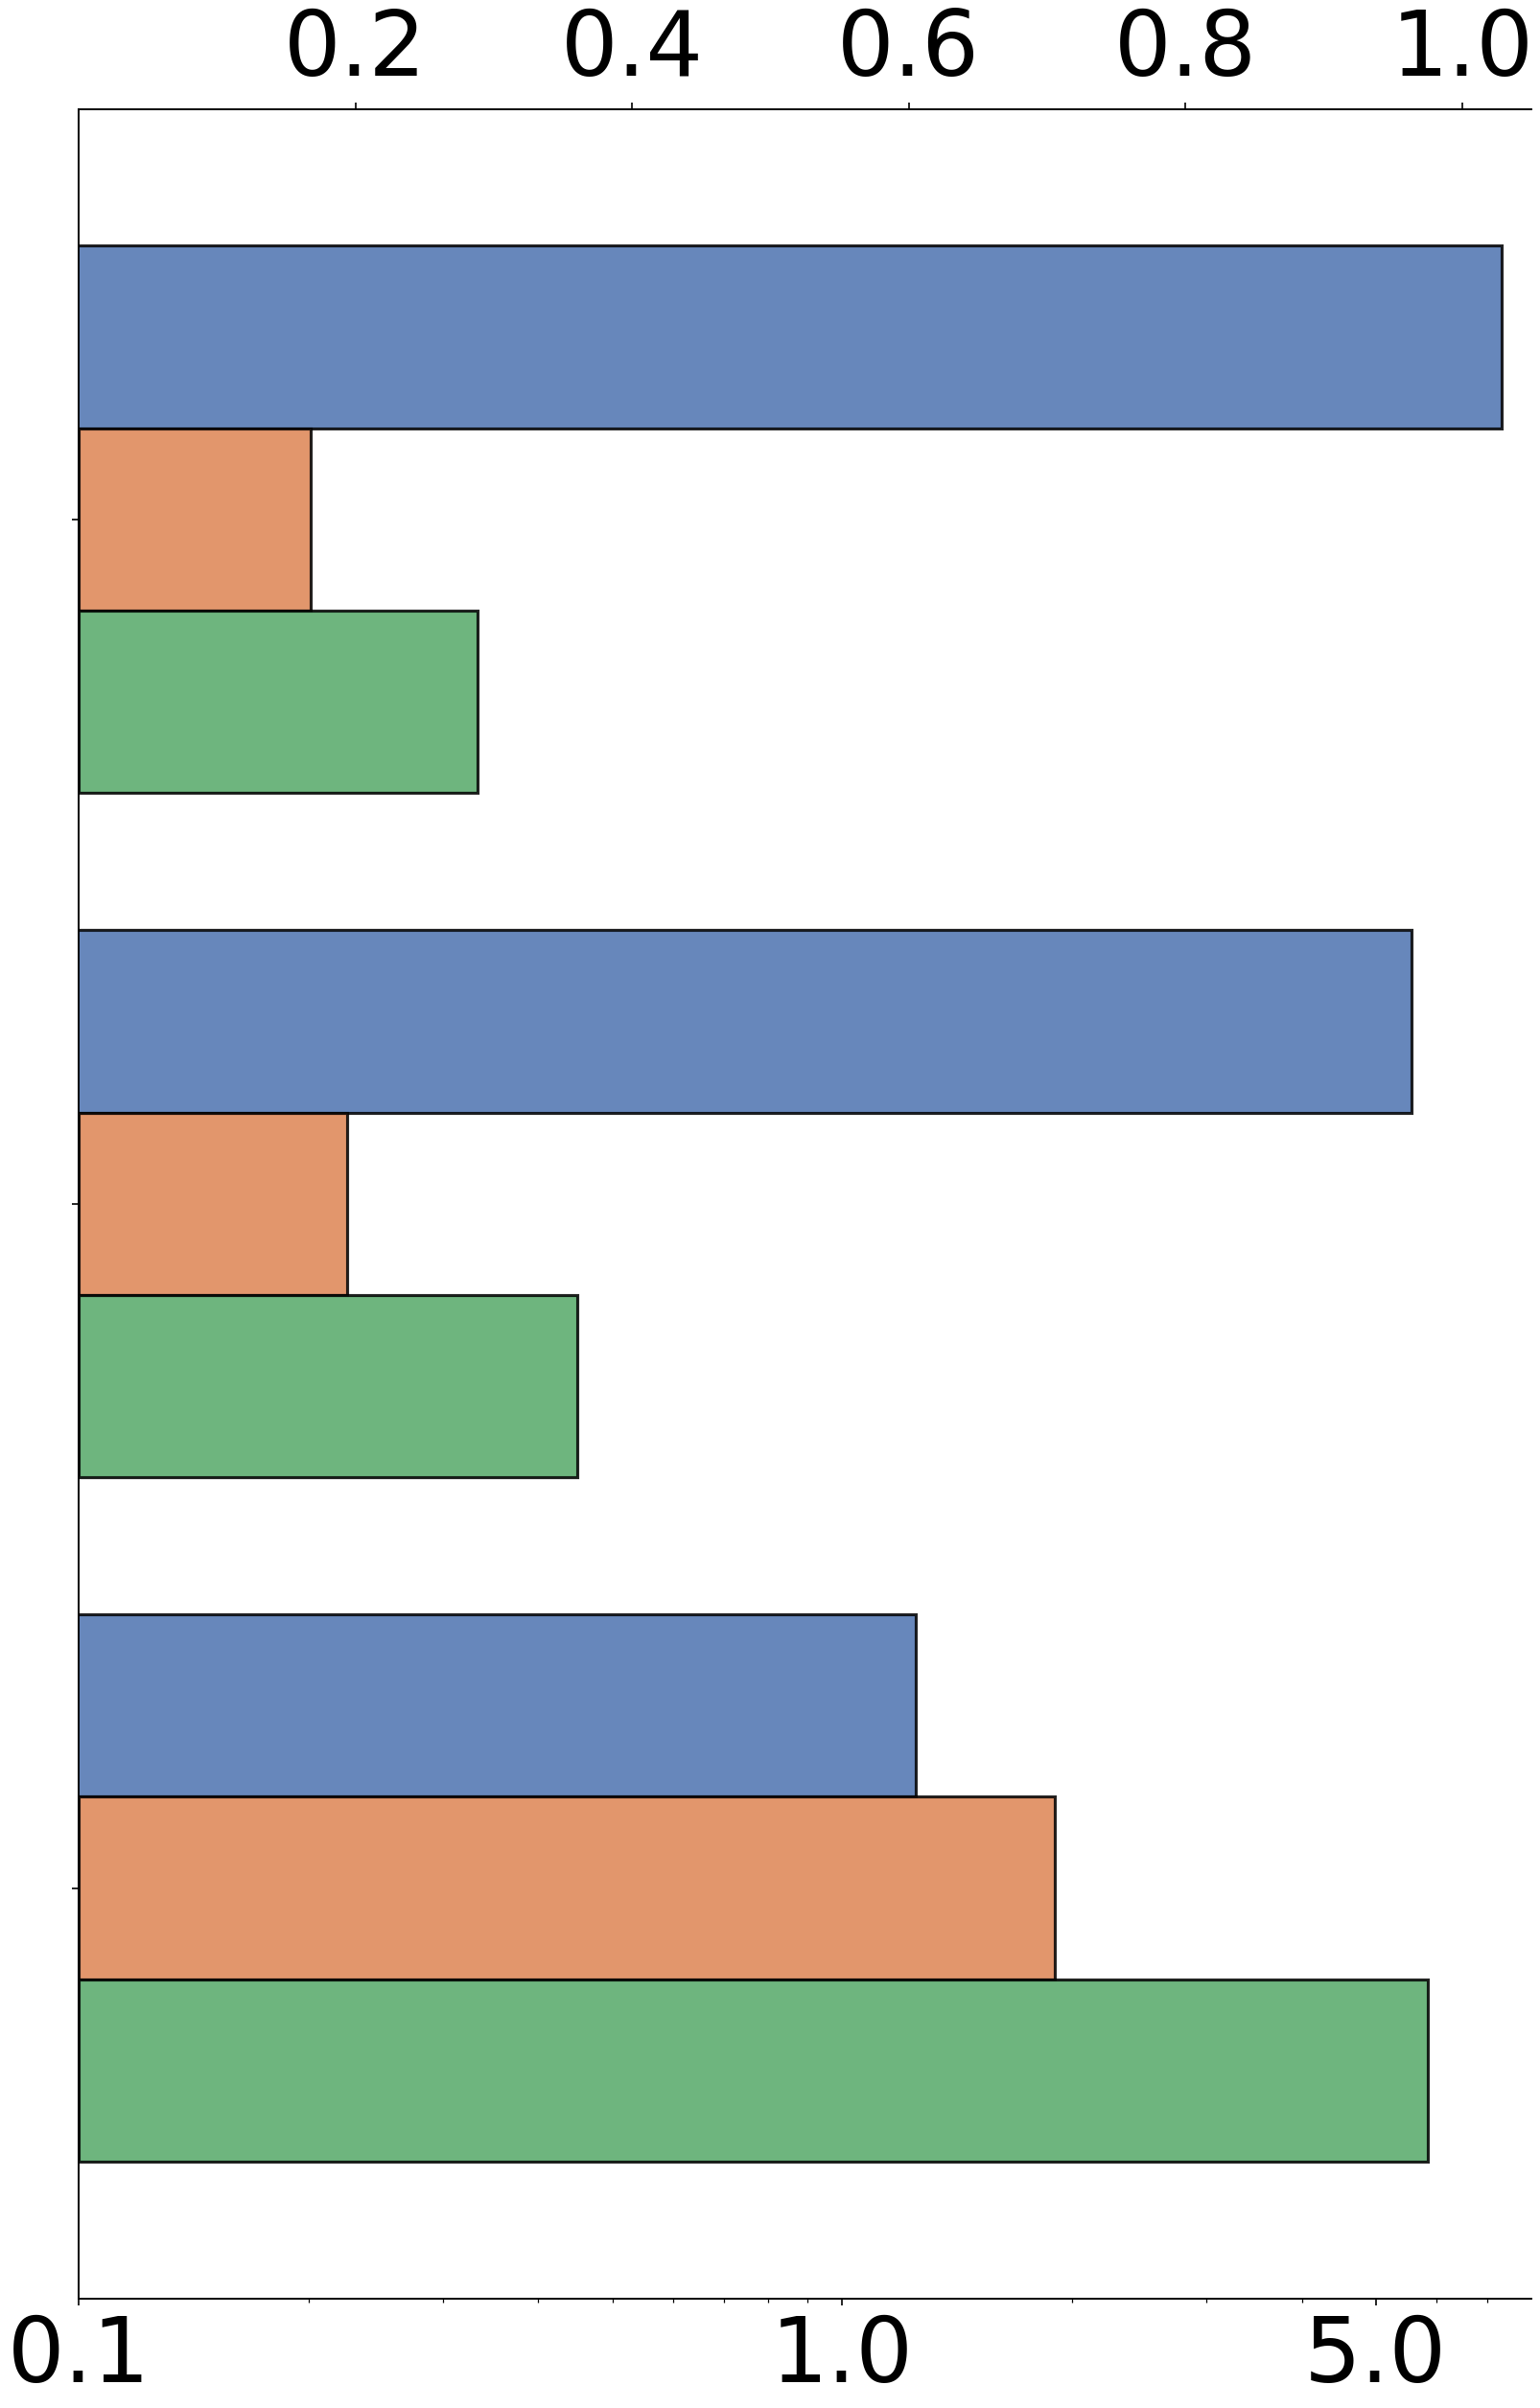

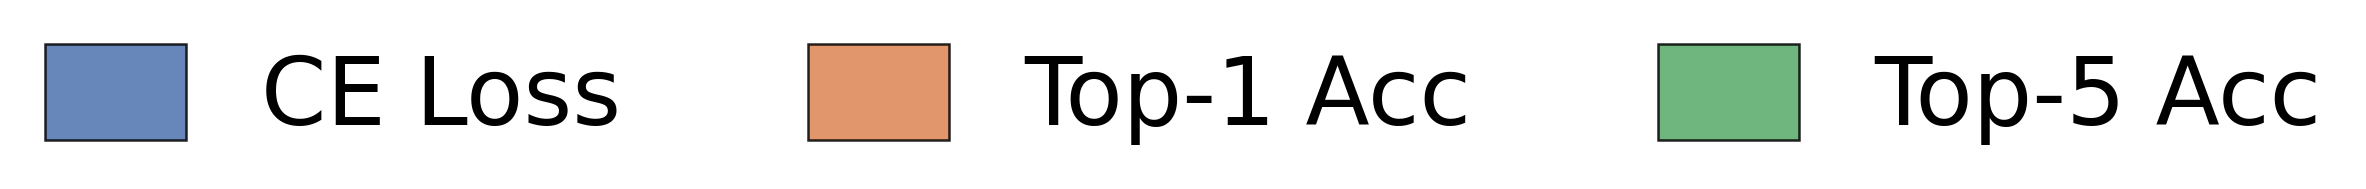

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# ---- merge ----
df_zncc_p = df_zncc[['ce_loss', 'top1', 'top5']].copy(); df_zncc_p['Method'] = 'ZNCC'
df_ssd_p  = df_ssd[['ce_loss', 'top1', 'top5']].copy();  df_ssd_p['Method'] = 'SSD'
df_mod_p  = df_model[['ce_loss', 'top1', 'top5']].copy(); df_mod_p['Method'] = 'CoarseFlow'
df_all = pd.concat([df_zncc_p, df_ssd_p, df_mod_p], ignore_index=True)

# ================================================================
# >>>>>  CONFIG  <<<<<
# ================================================================
FIG_W, FIG_H = 12, 18
METRIC_COLORS = ['#4C72B0', '#DD8452', '#55A868']  # CE, top1, top5
TICK_SIZE   = 45
LABEL_SIZE  = 45
LEGEND_SIZE = 45
GROUP_GAP = 1.5
BAR_H = 0.4
# ================================================================

METRICS = ['ce_loss', 'top1', 'top5']
METRIC_LABELS = ['CE Loss', 'Top-1 Acc', 'Top-5 Acc']
METHODS = ['ZNCC', 'SSD', 'CoarseFlow']

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.size': TICK_SIZE,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

out_dir = '/home/cyf/wbi/Virginia/code/CoarseFlow/baseline'

# ---- compute means ----
means = {m: [] for m in METRICS}
for method in METHODS:
    sub = df_all[df_all['Method'] == method]
    for metric in METRICS:
        vals = sub[metric].dropna()
        means[metric].append(vals.mean())

# y positions: one group per method, 3 bars per group
y = np.arange(len(METHODS)) * GROUP_GAP
offsets = [-BAR_H, 0, BAR_H]  # CE, top1, top5 offset from group center

# ================================================================
# Horizontal bar chart (swap x/y)
# ================================================================
fig, ax_bottom = plt.subplots(figsize=(FIG_W, FIG_H))
ax_top = ax_bottom.twiny()
ax_bottom.spines['right'].set_visible(False)
ax_top.spines['right'].set_visible(False)

for metric, label, color, off in zip(METRICS, METRIC_LABELS, METRIC_COLORS, offsets):
    x_vals = means[metric]
    if metric == 'ce_loss':
        ax_bottom.barh(y + off, x_vals, BAR_H, color=color, alpha=0.85,
                       edgecolor='black', linewidth=1.5)
    else:
        ax_top.barh(y + off, x_vals, BAR_H, color=color, alpha=0.85,
                    edgecolor='black', linewidth=1.5)

# bottom x-axis: CE — log10
ax_bottom.set_xscale('log', base=10)
ax_bottom.set_xticks([0.1, 1, 5])
ax_bottom.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_bottom.tick_params(axis='x', labelsize=TICK_SIZE, colors='black')
ax_bottom.set_xlabel('')

# top x-axis: accuracy
ax_top.set_xlim(0, 1.05)
ax_top.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_top.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax_top.tick_params(axis='x', labelsize=TICK_SIZE, colors='black')
ax_top.set_xlabel('')

# y-axis: method names
ax_bottom.set_yticks(y)
ax_bottom.set_yticklabels([])
ax_bottom.set_ylim(y[0] - GROUP_GAP * 0.6, y[-1] + GROUP_GAP * 0.6)
ax_bottom.invert_yaxis()  # ZNCC on top

fig.tight_layout()
fig.savefig(f'{out_dir}/fig_baseline_bar.pdf')
fig.savefig(f'{out_dir}/fig_baseline_bar.png')
print('Saved fig_baseline_bar.pdf / .png')

# ================================================================
# Standalone legend
# ================================================================
fig_leg, ax_leg = plt.subplots(figsize=(5, 1.3))
ax_leg.axis('off')
legend_elements = [
    Patch(facecolor=c, alpha=0.85, edgecolor='black', linewidth=1.2, label=lbl)
    for c, lbl in zip(METRIC_COLORS, METRIC_LABELS)
]
ax_leg.legend(handles=legend_elements, loc='center', ncol=3,
              frameon=False,
              fontsize=LEGEND_SIZE, handlelength=1.5, handleheight=1.2)
fig_leg.tight_layout()
fig_leg.savefig(f'{out_dir}/fig_legend.pdf')
fig_leg.savefig(f'{out_dir}/fig_legend.png')
print('Saved fig_legend.pdf / .png')
plt.show()


CoarseFlow vs ZNCC
----------------------------------------------------------------------
Model-ZNCC [CE]: mean diff=6.0691, better=19/20, worse=1/20, t-test p=1.67e-10, Wilcoxon p=3.81e-06
Model-ZNCC [top1]: mean diff=0.5381, better=19/20, worse=1/20, t-test p=5.18e-11, Wilcoxon p=3.81e-06
Model-ZNCC [top5]: mean diff=0.6874, better=20/20, worse=0/20, t-test p=1.16e-12, Wilcoxon p=1.91e-06

CoarseFlow vs SSD
----------------------------------------------------------------------
Model-SSD [CE]: mean diff=4.3160, better=20/20, worse=0/20, t-test p=2.51e-25, Wilcoxon p=1.91e-06
Model-SSD [top1]: mean diff=0.5117, better=19/20, worse=1/20, t-test p=4.09e-11, Wilcoxon p=3.81e-06
Model-SSD [top5]: mean diff=0.6149, better=20/20, worse=0/20, t-test p=1.65e-12, Wilcoxon p=1.91e-06

Saved fig_scatter_compare.pdf / .png


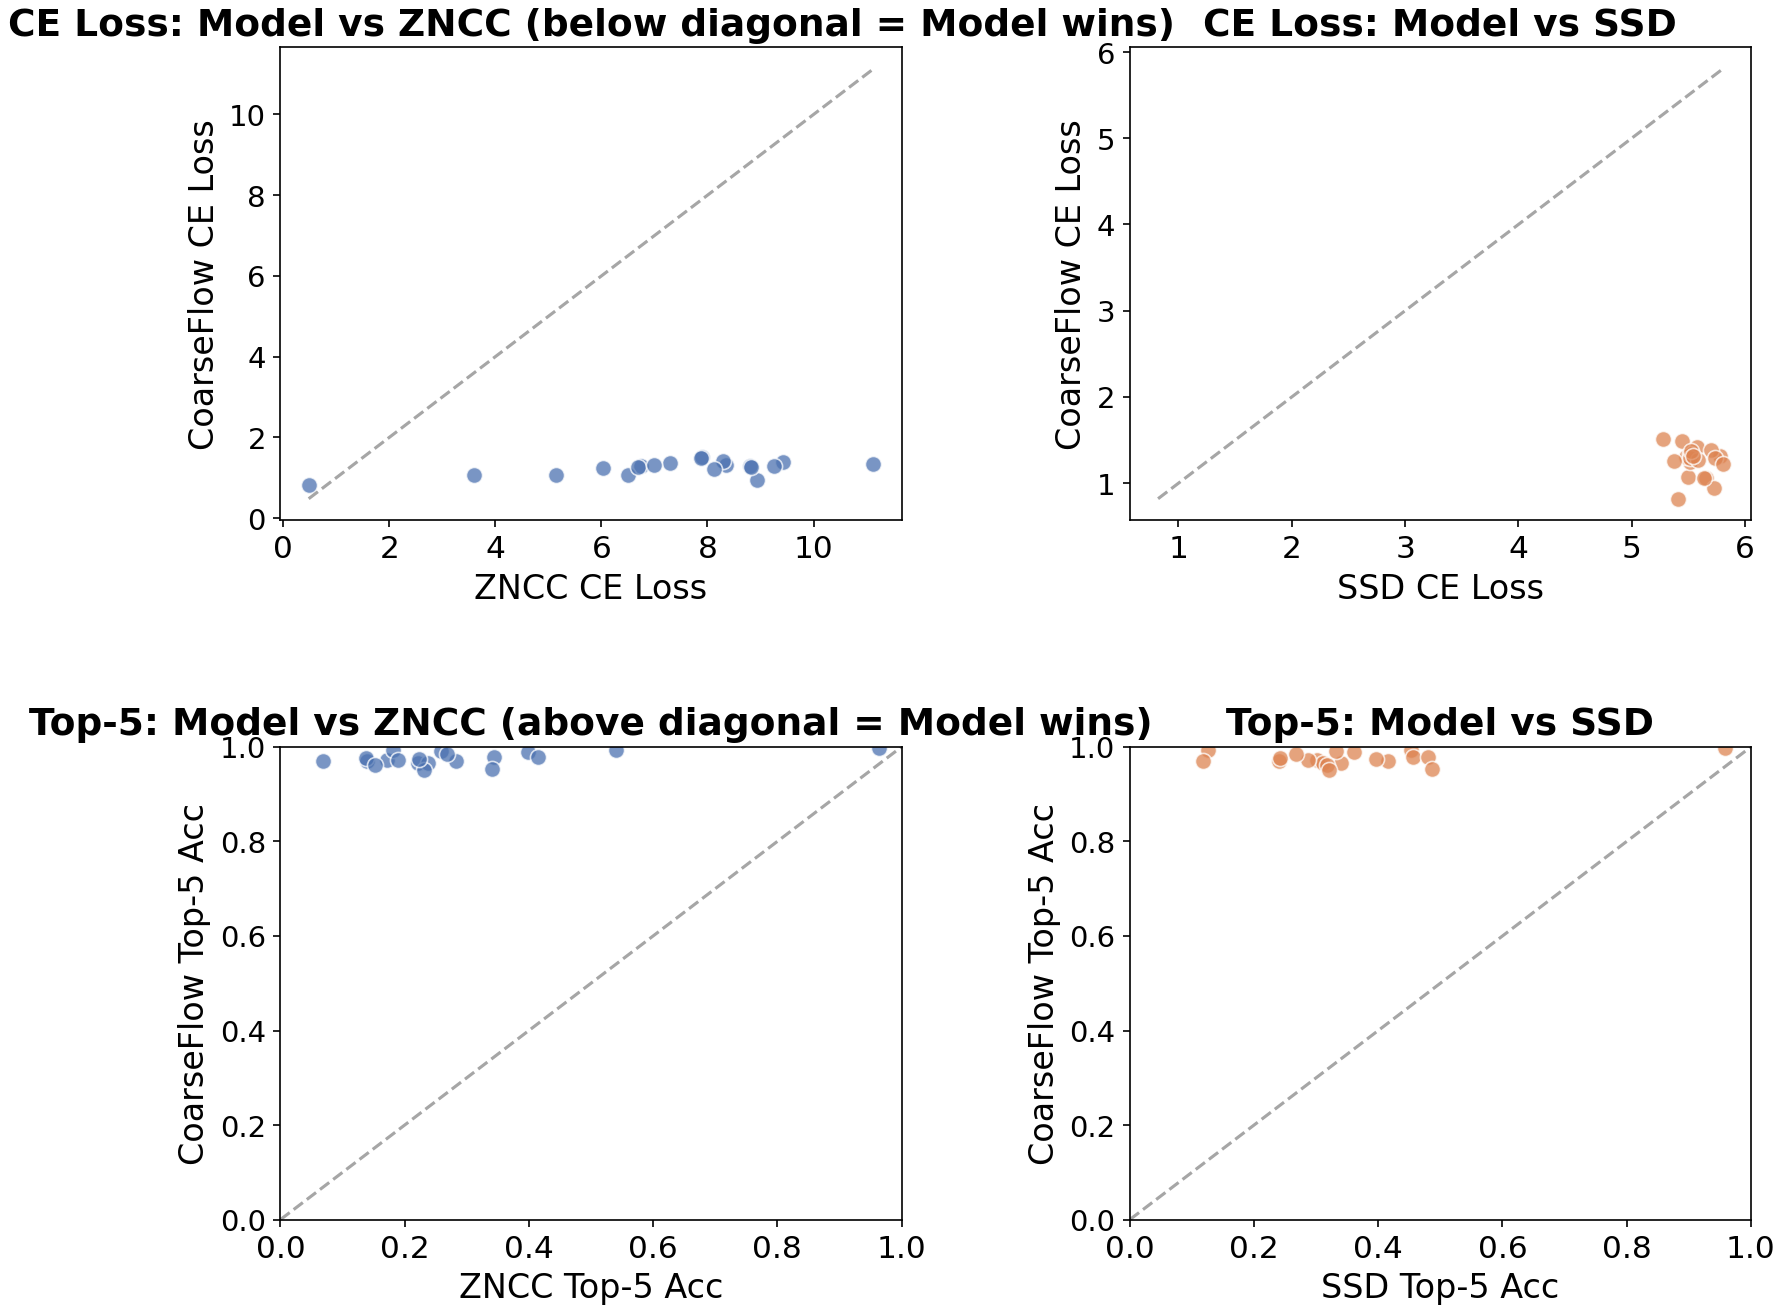

In [16]:
# ================================================================
# Per-sample paired comparison: Model vs ZNCC / SSD
# ================================================================
from scipy import stats

# Align samples by index (same loader, same order)
ce_zncc = df_zncc_p['ce_loss'].values
ce_ssd  = df_ssd_p['ce_loss'].values
ce_mod  = df_mod_p['ce_loss'].values
t1_zncc = df_zncc_p['top1'].values
t1_ssd  = df_ssd_p['top1'].values
t1_mod  = df_mod_p['top1'].values
t5_zncc = df_zncc_p['top5'].values
t5_ssd  = df_ssd_p['top5'].values
t5_mod  = df_mod_p['top5'].values

assert len(ce_mod) == len(ce_zncc) == len(ce_ssd), "sample counts must match"

# ---- statistical tests ----
def paired_test(name, a, b, metric_name):
    """Paired t-test + Wilcoxon, print results."""
    diff = a - b
    n = len(diff)
    t_stat, t_p = stats.ttest_rel(a, b)
    w_stat, w_p = stats.wilcoxon(a, b)
    n_better = (diff > 0).sum()
    n_worse  = (diff < 0).sum()
    print(f'{name} [{metric_name}]: mean diff={diff.mean():.4f}, '
          f'better={n_better}/{n}, worse={n_worse}/{n}, '
          f't-test p={t_p:.2e}, Wilcoxon p={w_p:.2e}')
    return diff

print('=' * 70)
print('CoarseFlow vs ZNCC')
print('-' * 70)
d_ce_z = paired_test('Model-ZNCC', ce_zncc, ce_mod, 'CE')  # positive = model better
d_t1_z = paired_test('Model-ZNCC', t1_mod, t1_zncc, 'top1')
d_t5_z = paired_test('Model-ZNCC', t5_mod, t5_zncc, 'top5')
print()
print('CoarseFlow vs SSD')
print('-' * 70)
d_ce_s = paired_test('Model-SSD', ce_ssd, ce_mod, 'CE')
d_t1_s = paired_test('Model-SSD', t1_mod, t1_ssd, 'top1')
d_t5_s = paired_test('Model-SSD', t5_mod, t5_ssd, 'top5')
print('=' * 70)

# ---- scatter: Model vs ZNCC (CE + top5) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scatter_kw = dict(s=60, alpha=0.75, edgecolors='white', linewidth=0.8)
diag_kw = dict(linestyle='--', color='gray', linewidth=1.5, alpha=0.7)

# CE: Model vs ZNCC
ax = axes[0, 0]
ax.scatter(ce_zncc, ce_mod, c='#4C72B0', **scatter_kw)
lo, hi = min(ce_zncc.min(), ce_mod.min()), max(ce_zncc.max(), ce_mod.max())
ax.plot([lo, hi], [lo, hi], **diag_kw)
ax.set_xlabel('ZNCC CE Loss'); ax.set_ylabel('CoarseFlow CE Loss')
ax.set_title('CE Loss: Model vs ZNCC (below diagonal = Model wins)', fontweight='bold')

# CE: Model vs SSD
ax = axes[0, 1]
ax.scatter(ce_ssd, ce_mod, c='#DD8452', **scatter_kw)
lo, hi = min(ce_ssd.min(), ce_mod.min()), max(ce_ssd.max(), ce_mod.max())
ax.plot([lo, hi], [lo, hi], **diag_kw)
ax.set_xlabel('SSD CE Loss'); ax.set_ylabel('CoarseFlow CE Loss')
ax.set_title('CE Loss: Model vs SSD', fontweight='bold')

# top5: Model vs ZNCC
ax = axes[1, 0]
ax.scatter(t5_zncc, t5_mod, c='#4C72B0', **scatter_kw)
ax.plot([0, 1], [0, 1], **diag_kw)
ax.set_xlabel('ZNCC Top-5 Acc'); ax.set_ylabel('CoarseFlow Top-5 Acc')
ax.set_title('Top-5: Model vs ZNCC (above diagonal = Model wins)', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# top5: Model vs SSD
ax = axes[1, 1]
ax.scatter(t5_ssd, t5_mod, c='#DD8452', **scatter_kw)
ax.plot([0, 1], [0, 1], **diag_kw)
ax.set_xlabel('SSD Top-5 Acc'); ax.set_ylabel('CoarseFlow Top-5 Acc')
ax.set_title('Top-5: Model vs SSD', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig(f'{out_dir}/fig_scatter_compare.pdf')
fig.savefig(f'{out_dir}/fig_scatter_compare.png')
print('\nSaved fig_scatter_compare.pdf / .png')
plt.show()


In [17]:
# ZNCC vs SSD vs Model 对比
print("=" * 60)
zncc_ce = df_zncc['ce_loss'].mean()
zncc_t1 = df_zncc['top1'].mean()
zncc_t5 = df_zncc['top5'].mean()
ssd_ce = df_ssd['ce_loss'].mean()
ssd_t1 = df_ssd['top1'].mean()
ssd_t5 = df_ssd['top5'].mean()
model_ce = df_model['ce_loss'].mean()
model_t1 = df_model['top1'].mean()
model_t5 = df_model['top5'].mean()
print(f'ZNCC   | CE={zncc_ce:.4f}  top1={zncc_t1:.4f}  top5={zncc_t5:.4f}')
print(f'SSD    | CE={ssd_ce:.4f}  top1={ssd_t1:.4f}  top5={ssd_t5:.4f}')
print(f'Model  | CE={model_ce:.4f}  top1={model_t1:.4f}  top5={model_t5:.4f}')
print("=" * 60)


ZNCC   | CE=7.3175  top1=0.1674  top5=0.2880
SSD    | CE=5.5644  top1=0.1939  top5=0.3605
Model  | CE=1.2484  top1=0.7055  top5=0.9754
